<a href="https://colab.research.google.com/github/Samiksha22911/AIML-LAB-EXPERIMENTS/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Experiment 1: Simple Linear Regression
Dataset: Home Price Dataset (No. of rooms vs. Price)

- Implements simple linear regression for a univariate dataset
- Evaluates using MSE and R-squared
- Visualizes the regression line
"""

'\nExperiment 1: Simple Linear Regression\nDataset: Home Price Dataset (No. of rooms vs. Price)\n\n- Implements simple linear regression for a univariate dataset\n- Evaluates using MSE and R-squared\n- Visualizes the regression line\n'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# 1. Load dataset

df = pd.read_csv("dataset_home_price.csv")
print("Dataset shape:", df.shape)
print(df.head())

X = df[["rooms"]].values          # feature: number of rooms
y = df["price_in_1000s"].values   # target: price (in $1000s)

Dataset shape: (130, 2)
   rooms  price_in_1000s
0      8           169.3
1      5           102.4
2      9           195.6
3      6           141.1
4      8           174.1


In [ ]:
# 2. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 3. Train model

model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nIntercept: {model.intercept_:.3f}")
print(f"Coefficient (price per room): {model.coef_[0]:.3f}")


Intercept: 26.648
Coefficient (price per room): 18.607


In [ ]:
# 4. Evaluate

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nMSE:  {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")


MSE:  235.189
RMSE: 15.336
R^2:  0.910



Saved plot -> regression_line.png


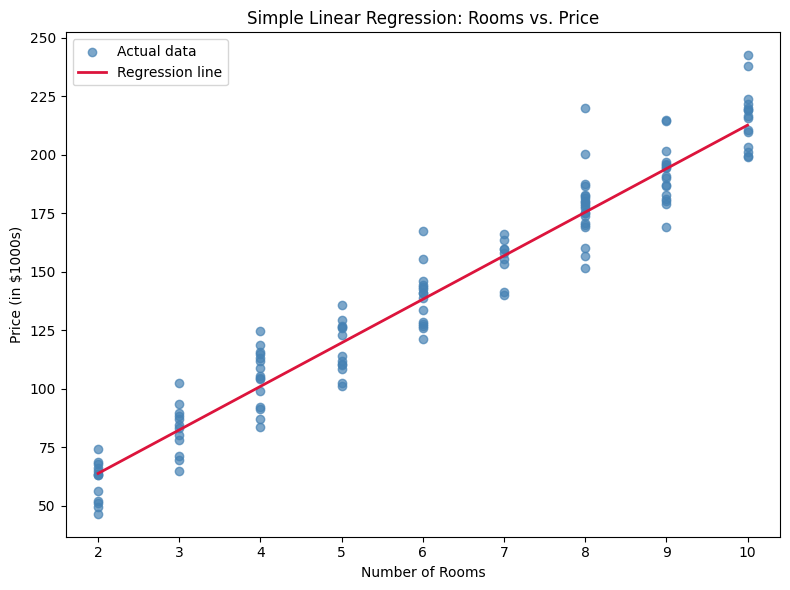

In [ ]:
# 5. Visualize regression line

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="steelblue", alpha=0.7, label="Actual data")

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color="crimson", linewidth=2, label="Regression line")

plt.xlabel("Number of Rooms")
plt.ylabel("Price (in $1000s)")
plt.title("Simple Linear Regression: Rooms vs. Price")
plt.legend()
plt.tight_layout()
plt.savefig("regression_line.png", dpi=150)
print("\nSaved plot -> regression_line.png")
plt.show()